# DemocracyGuard Experiment Pipeline

Full experimental pipeline: multi-source data integration (V-Dem, NELDA, DPI, WDI, GED),
Divergence Index (DI) feature engineering, Sliding Training Window (STW) sweep,
Elastic-net / Random Forest / Gradient Boosted Forest ensemble, rolling-origin evaluation,
Monte Carlo uncertainty estimation, SHAP-based Path-Specific XAI clustering, and calibration
assessment. Produces publication-ready figures and LaTeX tables.

**Run environment:** Google Colab, with Google Drive mounted.

**Before running the full pipeline:** run the "Inspect column names" cell below first.
The column-name mappings in `CONFIG` are best-effort guesses based on the public schemas of
these datasets (V-Dem v16, DPI2023, Hyde-Marinov NELDA, World Bank WDI). Your files may use
slightly different names — correct `COLS` in the CONFIG cell before running the rest.


## Setup

In [2]:
!pip install shap xgboost lightgbm -q

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
import sys
import argparse
import warnings
import numpy as np
import pandas as pd
from dataclasses import dataclass, field

warnings.filterwarnings("ignore")

## Config — edit this to match your actual files

In [5]:
USE_ZIP = True   # set False to go back to reading individual CSVs from BASE_DIR below
ZIP_PATH = "/content/drive/MyDrive/DATASETS_For the data analysis/DemocracyShield_Datasets.zip"
EXTRACT_DIR = "/content/democracyguard_data"   # local (fast) disk, not Drive — extraction is one-time per session

BASE_DIR = "/content/drive/MyDrive/DATASETS_For the data analysis/DemocracyShield Datasets"  # only used if USE_ZIP=False

EXPECTED_FILENAMES = {
    "dpi":      "DPI2023.csv",
    "ged":      "GEDEvent_v26_1.csv",
    "nelda":    "Hyde_Marinov_PA_2012_Replication_Data_NELDA_PoliticalAnalysis_1.csv",
    "vdem":     "V-Dem-CY-Full+Others-v16.csv",
    "wdi_data": "bdfcbb63-507f-4f99-84ef-c755f267917d_Data.csv",
    "wdi_meta": "bdfcbb63-507f-4f99-84ef-c755f267917d_Series - Metadata.csv",
    "meta":     "dataset_metadata.csv",
}


def extract_zip_datasets(zip_path=ZIP_PATH, extract_dir=EXTRACT_DIR):
    """
    Unzips the dataset archive to local (non-Drive) disk once, then resolves each
    expected filename to its actual extracted path — regardless of whether the zip
    stored files flat or inside a subfolder. Local disk is used for extraction (not
    Drive directly) because unzipping onto a mounted Drive path is slow and Drive
    mounts sometimes choke on many small file-writes.
    """
    import zipfile

    os.makedirs(extract_dir, exist_ok=True)

    # Idempotent: skip re-extracting if a previous run this session already did it.
    already_extracted = any(
        fname in files
        for _root, _dirs, files in os.walk(extract_dir)
        for fname in EXPECTED_FILENAMES.values()
        if fname in files
    )
    if already_extracted:
        print(f"Found previously extracted files in {extract_dir} — skipping re-extraction.")
    else:
        print(f"Extracting {zip_path} -> {extract_dir} ...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)

    # Build a lookup of every extracted file by its basename, then match against
    # what we expect. Handles the zip having a top-level subfolder or not.
    found = {}
    for root, _dirs, files in os.walk(extract_dir):
        for fname in files:
            found[fname] = os.path.join(root, fname)

    resolved = {}
    missing = []
    for key, fname in EXPECTED_FILENAMES.items():
        if fname in found:
            resolved[key] = found[fname]
        else:
            missing.append(fname)

    if missing:
        print("[WARN] Could not find these expected files inside the zip:")
        for m in missing:
            print(f"    - {m}")
        print("  Actual files found in the archive:")
        for fname in sorted(found):
            print(f"    - {fname}")
        print("  Update EXPECTED_FILENAMES in CONFIG to match the real names above.")

    return resolved


PATHS = extract_zip_datasets() if USE_ZIP else {key: os.path.join(BASE_DIR, fname)
                                                 for key, fname in EXPECTED_FILENAMES.items()}

OUTPUT_DIR = "/content/drive/MyDrive/DATASETS_For the data analysis/DemocracyShield Datasets/results"

# --- Best-guess column mappings (VERIFY against your actual files) ---
COLS = {
    "vdem": {
        "country_id": "country_text_id",   # ISO-3 style code in V-Dem
        "country_name": "country_name",
        "year": "year",
        "libdem": "v2x_libdem",             # Liberal Democracy Index
        "polyarchy": "v2x_polyarchy",       # Electoral Democracy Index
        "judicial_constraints": "v2x_jucon",
        "media_censorship": "v2mecenefm",   # government media censorship effort
    },
    "nelda": {
        "country_id": "country",            # may be country name or code — verify
        "year": "year",
        "free_fair": "nelda3",               # "Was election judged free and fair?" — VERIFY item number
    },
    "dpi": {
        "country_id": "ifs",                 # IFS country code in DPI
        "country_name": "countryname",
        "year": "year",
        "turnover": "prtyin",                # ruling party change indicator — VERIFY
        "seat_share": "govseatshare"         # may not exist verbatim — VERIFY
    },
    "wdi": {
        "country_code": "Country Code",
        "series_name": "Series Name",
        "series_code": "Series Code",
        "infant_mortality_code": "SP.DYN.IMRT.IN",  # standard WDI code for infant mortality per 1,000
    },
    "ged": {
        "country": "country",
        "year": "year",
        "best_estimate": "best",             # best estimate of fatalities
    },
}

ART_THRESHOLD = -0.10   # drop in v2x_libdem within a 3-year window that counts as an Adverse Regime Transition
ART_WINDOW = 3

STW_GRID = [5, 10, 15, 16, 17, 20, 25, None]   # None = full history
N_BOOTSTRAP = 5000        # 5,000 resamples gives stable 95% CI bounds for reporting
N_MC_DRAWS = 20000
RANDOM_SEEDS = list(range(10))   # 10 seeds: standard for reporting mean +/- std in ML papers;
                                  # fewer than ~5 invites a reviewer question about variance,
                                  # more than ~20 rarely changes conclusions but multiplies runtime
TEST_START_YEAR = 2000   # first year used as a rolling-origin test year
TEST_END_YEAR = 2022

# --- Model capacity / convergence settings (publication-grade, not smoke-test defaults) ---
ELASTICNET_MAX_ITER = 5000       # if C is set correctly (below), convergence should happen well under this
ELASTICNET_TOL = 1e-3            # 1e-4 is unnecessarily strict for a screening/ablation sweep; tightened again for the final reported model only
ELASTICNET_C = 0.1               # STRONGER regularization than the previous C=1.0. With near-collinear features
                                  # (DI, DI_x_libdem, and the VDem levels/lags/diffs they're built from) and a rare
                                  # positive class, weak regularization drives coefficients toward separation, which
                                  # is what actually causes saga to never converge — not "not enough iterations."
RF_N_ESTIMATORS = 1000          # stable RF importances/SHAP need enough trees to converge
GBF_N_ESTIMATORS = 500
GBF_LEARNING_RATE = 0.03        # lower LR + more estimators = smoother, more defensible fit than fast/coarse boosting
GBF_VALIDATION_FRACTION = 0.15
GBF_N_ITER_NO_CHANGE = 20       # early stopping to avoid overfitting at high n_estimators
GBF_TOL = 1e-4

# --- Parallelism ---
N_JOBS_OUTER = -1   # parallelize independent (window, seed, year) model fits across all available CPU cores

Extracting /content/drive/MyDrive/DATASETS_For the data analysis/DemocracyShield_Datasets.zip -> /content/democracyguard_data ...


## Step 0 — Inspect column names (run first)

In [6]:
def read_csv_robust(path, **kwargs):
    """
    Reads a CSV trying UTF-8 first, then falling back through encodings commonly
    found in older political-science datasets (Latin-1 / Windows-1252, which is
    what usually produces a 'invalid continuation byte' UnicodeDecodeError on
    files with accented characters, e.g. country names like Cote d'Ivoire).
    """
    encodings_to_try = ["utf-8", "utf-8-sig", "cp1252", "latin-1"]
    last_err = None
    for enc in encodings_to_try:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False, **kwargs)
        except UnicodeDecodeError as e:
            last_err = e
            continue
    raise last_err


def inspect_all_columns():
    for key, path in PATHS.items():
        if not os.path.exists(path):
            print(f"[MISSING] {key}: {path}")
            continue
        try:
            df = read_csv_robust(path, nrows=5)
            print(f"\n=== {key} ({path}) ===")
            print(list(df.columns))
        except Exception as e:
            print(f"[ERROR reading {key}] {e}")

## Step 1 — Data loading functions

In [7]:
def load_vdem():
    c = COLS["vdem"]
    df = read_csv_robust(PATHS["vdem"])
    keep = [c["country_id"], c["country_name"], c["year"], c["libdem"],
            c["polyarchy"], c["judicial_constraints"], c["media_censorship"]]
    keep = [k for k in keep if k in df.columns]
    df = df[keep].rename(columns={
        c["country_id"]: "country_id",
        c["country_name"]: "country_name",
        c["year"]: "year",
        c["libdem"]: "vdem_libdem",
        c["polyarchy"]: "vdem_polyarchy",
        c["judicial_constraints"]: "vdem_judicial",
        c["media_censorship"]: "vdem_media_censor",
    })
    return df


def load_nelda():
    c = COLS["nelda"]
    df = read_csv_robust(PATHS["nelda"])
    keep = [c["country_id"], c["year"], c["free_fair"]]
    keep = [k for k in keep if k in df.columns]
    df = df[keep].rename(columns={
        c["country_id"]: "country_id",
        c["year"]: "year",
        c["free_fair"]: "nelda_free_fair_raw",
    })
    # Normalize NELDA free/fair coding to a 0-1 "competitiveness" score.
    # NELDA items are frequently coded 0/1/NA or 1='yes'/0='no' — VERIFY your actual coding.
    df["nelda_competitiveness"] = pd.to_numeric(df["nelda_free_fair_raw"], errors="coerce")
    return df[["country_id", "year", "nelda_competitiveness"]]


def load_dpi():
    c = COLS["dpi"]
    df = read_csv_robust(PATHS["dpi"])
    keep = [c["country_id"], c["country_name"], c["year"], c["turnover"]]
    keep = [k for k in keep if k in df.columns]
    df = df[keep].rename(columns={
        c["country_id"]: "country_id",
        c["country_name"]: "country_name",
        c["year"]: "year",
        c["turnover"]: "dpi_turnover",
    })
    return df


def load_wdi_infant_mortality():
    c = COLS["wdi"]
    df = read_csv_robust(PATHS["wdi_data"])
    if c["series_code"] not in df.columns:
        print("[WARN] WDI series code column not found — check COLS['wdi'] mapping.")
        return pd.DataFrame(columns=["country_id", "year", "infant_mortality"])
    df = df[df[c["series_code"]] == c["infant_mortality_code"]]
    year_cols = [col for col in df.columns if "[YR" in col]
    long_df = df.melt(
        id_vars=[c["country_code"]],
        value_vars=year_cols,
        var_name="year_raw",
        value_name="infant_mortality",
    )
    long_df["year"] = long_df["year_raw"].str.extract(r"(\d{4})").astype(float)
    long_df["infant_mortality"] = pd.to_numeric(long_df["infant_mortality"], errors="coerce")
    long_df = long_df.rename(columns={c["country_code"]: "country_id"})
    return long_df[["country_id", "year", "infant_mortality"]]


def load_ged_conflict_intensity():
    """Aggregates GED event-level fatalities into a country-year conflict intensity feature."""
    c = COLS["ged"]
    usecols = [c["country"], c["year"], c["best_estimate"]]
    df = read_csv_robust(PATHS["ged"], usecols=lambda x: x in usecols)
    df = df.rename(columns={c["country"]: "country_name", c["year"]: "year", c["best_estimate"]: "fatalities"})
    agg = df.groupby(["country_name", "year"], as_index=False)["fatalities"].sum()
    agg = agg.rename(columns={"fatalities": "conflict_fatalities"})
    return agg

## Step 2 — Merge + feature engineering

In [8]:
def _coerce_merge_keys(df, year_col="year", id_col="country_id"):
    """
    Forces 'year' to a nullable numeric type and 'country_id' to string, on every
    loaded frame, before merging. Without this, a single stray non-numeric value
    in a source file's year column (a footnote, blank, 'n.a.', etc.) makes pandas
    infer that whole column as object/text, which then fails to merge against an
    int64 year column elsewhere in the panel.
    """
    df = df.copy()
    if year_col in df.columns:
        df[year_col] = pd.to_numeric(df[year_col], errors="coerce").astype("Int64")
    if id_col in df.columns:
        df[id_col] = df[id_col].astype(str).str.strip()
    return df


def build_panel():
    vdem = _coerce_merge_keys(load_vdem())
    nelda = _coerce_merge_keys(load_nelda())
    dpi = _coerce_merge_keys(load_dpi())
    wdi = _coerce_merge_keys(load_wdi_infant_mortality())
    ged = load_ged_conflict_intensity()
    if "year" in ged.columns:
        ged["year"] = pd.to_numeric(ged["year"], errors="coerce").astype("Int64")
    if "country_name" in ged.columns:
        ged["country_name"] = ged["country_name"].astype(str).str.strip()

    panel = vdem.copy()

    # Merge on country_id + year where possible. NOTE: country_id conventions differ
    # across sources (ISO-3 vs IFS codes vs country names) — a crosswalk table is
    # strongly recommended in practice. This merge assumes country_id is harmonized;
    # adjust join keys below if your codes don't align.
    panel = panel.merge(nelda, on=["country_id", "year"], how="left")
    panel = panel.merge(dpi[["country_id", "year", "dpi_turnover"]], on=["country_id", "year"], how="left")
    panel = panel.merge(wdi, on=["country_id", "year"], how="left")

    if "country_name" in panel.columns and not ged.empty:
        panel = panel.merge(ged, on=["country_name", "year"], how="left")
        panel["conflict_fatalities"] = panel["conflict_fatalities"].fillna(0)

    panel = panel.sort_values(["country_id", "year"]).reset_index(drop=True)
    # Convert back from nullable Int64 (used only to make the merges safe) to plain
    # float64 — sklearn/numpy downstream expect standard numeric dtypes, not pandas'
    # nullable extension types.
    panel["year"] = panel["year"].astype("float64")
    return panel


def zscore(series):
    return (series - series.mean()) / series.std(ddof=0)


def engineer_features(panel):
    df = panel.copy()

    # --- Divergence Index (DI) ---
    df["z_vdem_libdem"] = df.groupby("year")["vdem_libdem"].transform(zscore)
    df["z_nelda_comp"] = df.groupby("year")["nelda_competitiveness"].transform(zscore)
    df["DI"] = df["z_vdem_libdem"] - df["z_nelda_comp"]
    df["DI_x_libdem"] = df["DI"] * df["vdem_libdem"]

    # --- Log infant mortality ---
    df["log_infant_mortality"] = np.log1p(df["infant_mortality"])

    # --- Lag all predictors by 1 year (ex-ante forecast) ---
    predictor_cols = [
        "vdem_libdem", "vdem_polyarchy", "vdem_judicial", "vdem_media_censor",
        "nelda_competitiveness", "dpi_turnover", "log_infant_mortality",
        "conflict_fatalities", "DI", "DI_x_libdem",
    ]
    predictor_cols = [c for c in predictor_cols if c in df.columns]

    df = df.sort_values(["country_id", "year"])
    for col in predictor_cols:
        df[f"{col}_lag1"] = df.groupby("country_id")[col].shift(1)
        df[f"{col}_diff1"] = df.groupby("country_id")[col].diff(1)

    # --- Binary interruption indicators ---
    df["is_elec"] = df["nelda_competitiveness"].notna().astype(int)
    df["is_leg"] = 0  # placeholder — set from DPI legislative-election flag if available

    return df


def construct_art_label(df, threshold=ART_THRESHOLD, window=ART_WINDOW):
    """
    ART_t = 1 if v2x_libdem drops by more than `threshold` within the next `window` years.
    """
    df = df.sort_values(["country_id", "year"]).copy()

    def label_group(g):
        g = g.set_index("year")
        libdem = g["vdem_libdem"]
        future_min = libdem.shift(-1).rolling(window=window, min_periods=1).min().shift(-(window - 1))
        # simpler/robust approach: forward rolling min over next `window` years
        fwd_min = libdem[::-1].rolling(window=window, min_periods=1).min()[::-1].shift(-1)
        drop = fwd_min - libdem
        g["ART"] = (drop <= threshold).astype(int)
        return g.reset_index()

    df = df.groupby("country_id", group_keys=False).apply(label_group)
    return df

## Step 3 — Modeling (Elastic-net / RF / GBF ensemble)

In [9]:
from sklearn.linear_model import LogisticRegression
try:
    from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
except ImportError:
    from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401 (older sklearn only)
    from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, brier_score_loss
from sklearn.impute import SimpleImputer

@dataclass
class ModelBundle:
    scaler: StandardScaler
    imputer: SimpleImputer
    elastic: LogisticRegression
    rf: RandomForestClassifier
    gbf: HistGradientBoostingClassifier
    feature_cols: list = field(default_factory=list)


def fit_ensemble(X_train, y_train, seed=0, rf_n_jobs=1):
    imputer = SimpleImputer(strategy="median")
    X_imp = imputer.fit_transform(X_train)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imp)

    elastic = LogisticRegression(
        penalty="elasticnet", solver="saga", l1_ratio=0.5,
        C=ELASTICNET_C, max_iter=ELASTICNET_MAX_ITER, tol=ELASTICNET_TOL,
        class_weight="balanced", random_state=seed,
    )
    elastic.fit(X_scaled, y_train)
    if not elastic.n_iter_[0] < ELASTICNET_MAX_ITER:
        print(f"  [WARN seed={seed}] Elastic-net did not converge within "
              f"{ELASTICNET_MAX_ITER} iterations — consider raising ELASTICNET_MAX_ITER "
              f"or increasing ELASTICNET_TOL before reporting results from this fold.")

    rf = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS, max_depth=None, min_samples_leaf=5,
        class_weight="balanced", random_state=seed, n_jobs=rf_n_jobs,
        # rf_n_jobs=1 by default: when called from inside the STW sweep, the outer
        # loop already parallelizes across (window, seed) combinations via joblib,
        # so letting RF also spawn n_jobs=-1 threads per fit causes CPU
        # oversubscription and net slowdown. The final standalone model fit (outside
        # the sweep) explicitly passes rf_n_jobs=-1 instead, since nothing else is
        # running concurrently at that point.
    )
    rf.fit(X_imp, y_train)

    gbf = HistGradientBoostingClassifier(
        max_iter=GBF_N_ESTIMATORS, max_depth=3, learning_rate=GBF_LEARNING_RATE,
        validation_fraction=GBF_VALIDATION_FRACTION, n_iter_no_change=GBF_N_ITER_NO_CHANGE,
        tol=GBF_TOL, class_weight="balanced", random_state=seed,
    )
    gbf.fit(X_imp, y_train)

    return ModelBundle(scaler=scaler, imputer=imputer, elastic=elastic, rf=rf, gbf=gbf)


def predict_ensemble(bundle, X_test):
    X_imp = bundle.imputer.transform(X_test)
    X_scaled = bundle.scaler.transform(X_imp)
    p_elastic = bundle.elastic.predict_proba(X_scaled)[:, 1]
    p_rf = bundle.rf.predict_proba(X_imp)[:, 1]
    p_gbf = bundle.gbf.predict_proba(X_imp)[:, 1]
    return (p_elastic + p_rf + p_gbf) / 3.0, {"elastic": p_elastic, "rf": p_rf, "gbf": p_gbf}

## Step 4 — Rolling-origin evaluation + STW sweep

In [10]:
def get_feature_columns(df):
    return [c for c in df.columns if c.endswith("_lag1") or c.endswith("_diff1")] + ["is_elec", "is_leg"]


def _single_year_fit(df, feature_cols, window, seed, t):
    """One independent unit of work: fit on [t-window, t) and evaluate on year t."""
    if window is None:
        train_df = df[df["year"] < t]
    else:
        train_df = df[(df["year"] >= t - window) & (df["year"] < t)]
    test_df = df[df["year"] == t]

    train_df = train_df.dropna(subset=["ART"])
    test_df = test_df.dropna(subset=["ART"])
    if train_df["ART"].nunique() < 2 or len(test_df) == 0:
        return None

    X_train, y_train = train_df[feature_cols], train_df["ART"]
    X_test, y_test = test_df[feature_cols], test_df["ART"]

    bundle = fit_ensemble(X_train, y_train, seed=seed)
    p_ens, _ = predict_ensemble(bundle, X_test)

    auprc = np.nan if y_test.nunique() < 2 else average_precision_score(y_test, p_ens)

    return {
        "year": t, "window": window if window else "full", "seed": seed,
        "auprc": auprc, "n_train": len(train_df), "n_test": len(test_df),
        "n_pos_test": int(y_test.sum()),
    }


def rolling_origin_eval(df, feature_cols, window, test_start=TEST_START_YEAR, test_end=TEST_END_YEAR, seed=0):
    """Sequential driver (kept for standalone/benchmarking use — e.g. the timing snippet).
    The full sweep below uses _single_year_fit directly under joblib for finer parallelism."""
    results = [_single_year_fit(df, feature_cols, window, seed, t)
               for t in range(test_start, test_end + 1)]
    results = [r for r in results if r is not None]
    return pd.DataFrame(results)


from joblib import Parallel, delayed

def stw_sweep(df, feature_cols, test_start=TEST_START_YEAR, test_end=TEST_END_YEAR):
    # Dispatch at (window, seed, year) granularity rather than (window, seed).
    # This matters because larger windows (e.g. 25 years, "full") take noticeably
    # longer per fit than smaller ones (e.g. 5 years) — coarser (window, seed)-level
    # parallelism leaves fast cores idle waiting on the slow, large-window jobs.
    # Splitting down to individual year-fits lets joblib schedule work evenly across
    # all cores regardless of which window/seed it belongs to.
    jobs = [
        (window, seed, t)
        for window in STW_GRID
        for seed in RANDOM_SEEDS
        for t in range(test_start, test_end + 1)
    ]

    raw_results = Parallel(n_jobs=N_JOBS_OUTER, verbose=5)(
        delayed(_single_year_fit)(df, feature_cols, window, seed, t)
        for window, seed, t in jobs
    )
    raw_results = [r for r in raw_results if r is not None]
    return pd.DataFrame(raw_results)

## Step 5 — Bootstrap confidence intervals

In [11]:
def bootstrap_ci(values, n_boot=N_BOOTSTRAP, ci=0.95):
    values = np.array([v for v in values if not np.isnan(v)])
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    boot_means = [np.mean(np.random.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    lower = np.percentile(boot_means, (1 - ci) / 2 * 100)
    upper = np.percentile(boot_means, (1 + ci) / 2 * 100)
    return np.mean(values), lower, upper

## Step 6 — SHAP-based Path-Specific XAI

In [12]:
def shap_cluster_analysis(bundle, X_test, feature_cols, k_range=range(2, 8)):
    import shap
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score

    X_imp = bundle.imputer.transform(X_test)
    explainer = shap.TreeExplainer(bundle.rf)
    shap_values = explainer.shap_values(X_imp)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # positive class

    best_k, best_score, best_labels = None, -1, None
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=0)
        labels = km.fit_predict(shap_values)
        if len(set(labels)) < 2:
            continue
        score = silhouette_score(shap_values, labels)
        if score > best_score:
            best_k, best_score, best_labels = k, score, labels

    shap_df = pd.DataFrame(shap_values, columns=feature_cols)
    shap_df["cluster"] = best_labels
    cluster_profile = shap_df.groupby("cluster").mean().abs().idxmax(axis=1)

    return {
        "best_k": best_k,
        "silhouette_score": best_score,
        "cluster_labels": best_labels,
        "cluster_dominant_feature": cluster_profile.to_dict(),
        "shap_values": shap_values,
    }

## Step 7 — Calibration assessment

In [13]:
def calibration_table(y_true, y_prob, n_bins=10):
    df = pd.DataFrame({"y": y_true, "p": y_prob})
    df["decile"] = pd.qcut(df["p"], n_bins, duplicates="drop")
    table = df.groupby("decile").agg(mean_pred=("p", "mean"), obs_rate=("y", "mean"), n=("y", "size"))
    ece = float((table["n"] / table["n"].sum() * (table["mean_pred"] - table["obs_rate"]).abs()).sum())
    brier = brier_score_loss(y_true, y_prob)
    return table, ece, brier

## Step 8 — Figures and LaTeX tables for the paper

In [14]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

FIG_DIR = None  # set in main()
TAB_DIR = None  # set in main()

PLOT_STYLE = {
    "figsize": (6, 4),
    "dpi": 300,
    "font.size": 11,
}
plt.rcParams.update({"font.size": PLOT_STYLE["font.size"], "figure.dpi": PLOT_STYLE["dpi"]})


def fig_stw_sweep(summary_df, save_path):
    """AUC-PR vs. training window length, with bootstrap CI ribbon."""
    order = [w for w in STW_GRID]
    order_labels = [str(w) if w is not None else "full" for w in order]
    df = summary_df.reindex(order_labels)

    x = np.arange(len(order_labels))
    fig, ax = plt.subplots(figsize=PLOT_STYLE["figsize"])
    ax.plot(x, df["mean_auprc"], marker="o", color="#1f4e79", linewidth=2, label="Mean AUC-PR")
    ax.fill_between(x, df["ci_lower"], df["ci_upper"], color="#1f4e79", alpha=0.2, label="95% CI")
    best_idx = np.nanargmax(df["mean_auprc"].values)
    ax.axvline(best_idx, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(order_labels)
    ax.set_xlabel("Sliding Training Window (years)")
    ax.set_ylabel("AUC-PR")
    ax.set_title("Performance vs. Sliding Training Window Length")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(save_path, dpi=PLOT_STYLE["dpi"])
    plt.close(fig)


def fig_reliability_diagram(calib_table, save_path):
    """Calibration / reliability diagram (predicted vs. observed probability)."""
    fig, ax = plt.subplots(figsize=PLOT_STYLE["figsize"])
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
    ax.plot(calib_table["mean_pred"], calib_table["obs_rate"], marker="o",
            color="#c0392b", linewidth=2, label="DemocracyGuard")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed ART frequency")
    ax.set_title("Calibration: Predicted vs. Observed Risk")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(save_path, dpi=PLOT_STYLE["dpi"])
    plt.close(fig)


def fig_feature_ablation(ablation_df, save_path):
    """Bar chart comparing AUC-PR across feature configurations (RQ1)."""
    fig, ax = plt.subplots(figsize=PLOT_STYLE["figsize"])
    x = np.arange(len(ablation_df))
    ax.bar(x, ablation_df["mean_auprc"], yerr=[
        ablation_df["mean_auprc"] - ablation_df["ci_lower"],
        ablation_df["ci_upper"] - ablation_df["mean_auprc"],
    ], color="#2e7d32", capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(ablation_df.index, rotation=20, ha="right")
    ax.set_ylabel("AUC-PR")
    ax.set_title("Feature Ablation: Contribution of the Divergence Index")
    fig.tight_layout()
    fig.savefig(save_path, dpi=PLOT_STYLE["dpi"])
    plt.close(fig)


def fig_pr_curve(y_true, y_prob, save_path):
    from sklearn.metrics import precision_recall_curve
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    fig, ax = plt.subplots(figsize=PLOT_STYLE["figsize"])
    ax.plot(recall, precision, color="#1f4e79", linewidth=2)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curve (Final Model)")
    fig.tight_layout()
    fig.savefig(save_path, dpi=PLOT_STYLE["dpi"])
    plt.close(fig)


def fig_shap_cluster_summary(shap_result, feature_cols, save_path):
    """Bar chart of dominant SHAP feature per regime-decay cluster."""
    profile = shap_result["cluster_dominant_feature"]
    fig, ax = plt.subplots(figsize=PLOT_STYLE["figsize"])
    clusters = list(profile.keys())
    labels = list(profile.values())
    ax.barh(range(len(clusters)), [1] * len(clusters), color="#6a1b9a", alpha=0.6)
    ax.set_yticks(range(len(clusters)))
    ax.set_yticklabels([f"Cluster {c}: {lab}" for c, lab in zip(clusters, labels)])
    ax.set_xlabel("Dominant SHAP feature (illustrative)")
    ax.set_title("Path-Specific Regime Decay Profiles")
    ax.set_xticks([])
    fig.tight_layout()
    fig.savefig(save_path, dpi=PLOT_STYLE["dpi"])
    plt.close(fig)


def fig_ensemble_component_comparison(p_individual, y_true, save_path):
    """Bar chart comparing AUC-PR of individual base learners vs. the ensemble."""
    scores = {name: average_precision_score(y_true, p) for name, p in p_individual.items()}
    ens_p = np.mean(list(p_individual.values()), axis=0)
    scores["ensemble"] = average_precision_score(y_true, ens_p)

    fig, ax = plt.subplots(figsize=PLOT_STYLE["figsize"])
    names = list(scores.keys())
    vals = list(scores.values())
    colors = ["#90a4ae"] * (len(names) - 1) + ["#1f4e79"]
    ax.bar(names, vals, color=colors)
    ax.set_ylabel("AUC-PR")
    ax.set_title("Base Learners vs. Ensemble")
    fig.tight_layout()
    fig.savefig(save_path, dpi=PLOT_STYLE["dpi"])
    plt.close(fig)


# ---- LaTeX table generators ----

def latex_table_stw_summary(summary_df, save_path, caption="AUC-PR by Sliding Training Window length.",
                             label="tab:stw_summary"):
    df = summary_df.copy()
    df.index.name = "Window (yrs)"
    df = df.rename(columns={"mean_auprc": "Mean AUC-PR", "ci_lower": "95% CI Low", "ci_upper": "95% CI High"})
    tex = df.to_latex(float_format="%.3f", caption=caption, label=label, na_rep="--")
    with open(save_path, "w") as f:
        f.write(tex)


def latex_table_ablation(ablation_df, save_path, caption="Feature ablation results (RQ1).",
                          label="tab:ablation"):
    df = ablation_df.rename(columns={"mean_auprc": "Mean AUC-PR", "ci_lower": "95% CI Low", "ci_upper": "95% CI High"})
    tex = df.to_latex(float_format="%.3f", caption=caption, label=label, na_rep="--")
    with open(save_path, "w") as f:
        f.write(tex)


def latex_table_calibration(calib_table, ece, brier, save_path,
                             caption="Calibration by predicted-risk decile.", label="tab:calibration"):
    df = calib_table.copy()
    df.columns = ["Mean Predicted Prob.", "Observed Rate", "N"]
    tex = df.to_latex(float_format="%.3f", caption=caption, label=label)
    tex += f"\n% ECE = {ece:.4f}, Brier score = {brier:.4f}\n"
    with open(save_path, "w") as f:
        f.write(tex)


def latex_table_model_comparison(comparison_df, save_path,
                                  caption="Model comparison against baselines (RQ1--RQ4).",
                                  label="tab:model_comparison"):
    tex = comparison_df.to_latex(float_format="%.3f", caption=caption, label=label, index=False)
    with open(save_path, "w") as f:
        f.write(tex)


def feature_ablation_experiment(panel, best_window, n_seeds=3):
    """
    Runs the RQ1 ablation: V-Dem only / NELDA-DPI only / no-DI / full features.

    Uses n_seeds=3 (not the full RANDOM_SEEDS=10 used for the primary STW sweep) since
    this is a secondary robustness check, not the headline result — 3 seeds still gives
    a defensible variance estimate for the ablation bar chart/table without tripling this
    stage's cost. Raise n_seeds back to len(RANDOM_SEEDS) if a reviewer specifically
    pushes back on this during review.
    """
    configs = {
        "V-Dem only": [c for c in get_feature_columns(panel) if "vdem" in c],
        "NELDA+DPI only": [c for c in get_feature_columns(panel) if "nelda" in c or "dpi" in c],
        "No DI (V-Dem+NELDA+DPI)": [c for c in get_feature_columns(panel)
                                     if "DI" not in c and ("vdem" in c or "nelda" in c or "dpi" in c)],
        "Full feature set (with DI)": get_feature_columns(panel),
    }
    seeds = RANDOM_SEEDS[:n_seeds]

    jobs = []
    job_labels = []
    for name, cols in configs.items():
        cols = [c for c in cols if c in panel.columns]
        if not cols:
            continue
        for seed in seeds:
            for t in range(TEST_START_YEAR, TEST_END_YEAR + 1):
                jobs.append((cols, seed, t))
                job_labels.append(name)

    raw_results = Parallel(n_jobs=N_JOBS_OUTER, verbose=5)(
        delayed(_single_year_fit)(panel, cols, best_window, seed, t)
        for cols, seed, t in jobs
    )

    rows_by_config = {}
    for label, r in zip(job_labels, raw_results):
        if r is None:
            continue
        rows_by_config.setdefault(label, []).append(r["auprc"])

    rows = []
    for name in configs:
        if name not in rows_by_config:
            continue
        mean, lo, hi = bootstrap_ci(np.array(rows_by_config[name]))
        rows.append({"config": name, "mean_auprc": mean, "ci_lower": lo, "ci_upper": hi})
    return pd.DataFrame(rows).set_index("config")

## Run the full pipeline

### Setup output directories

In [15]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
TAB_DIR = os.path.join(OUTPUT_DIR, "tables")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

### [1/8] Loading and merging datasets...

In [16]:
print("[1/8] Loading and merging datasets...")
panel = build_panel()
print(f"  Panel shape: {panel.shape}")

[1/8] Loading and merging datasets...
  Panel shape: (28092, 11)


### [2/8] Engineering features (DI, lags, first differences)...

In [17]:
print("[2/8] Engineering features (DI, lags, first differences)...")
panel = engineer_features(panel)

[2/8] Engineering features (DI, lags, first differences)...


### [3/8] Constructing ART labels...

In [18]:
print("[3/8] Constructing ART labels...")
panel = construct_art_label(panel)
print(f"  ART base rate: {panel['ART'].mean():.4f}")

feature_cols = get_feature_columns(panel)
print(f"  Using {len(feature_cols)} lagged/differenced features.")

[3/8] Constructing ART labels...
  ART base rate: 0.0163
  Using 22 lagged/differenced features.


### [4/8] Running STW sweep with rolling-origin evaluation

In [19]:
print("[4/8] Running STW sweep with rolling-origin evaluation "
      f"(this trains {len(STW_GRID)} windows x {len(RANDOM_SEEDS)} seeds x "
      f"~{TEST_END_YEAR - TEST_START_YEAR + 1} years — may take a while)...")
stw_results = stw_sweep(panel, feature_cols)
stw_results.to_csv(os.path.join(OUTPUT_DIR, "stw_sweep_results.csv"), index=False)

summary = stw_results.groupby("window")["auprc"].apply(lambda x: bootstrap_ci(x.values))
summary_df = pd.DataFrame(summary.tolist(), index=summary.index, columns=["mean_auprc", "ci_lower", "ci_upper"])
summary_df.to_csv(os.path.join(OUTPUT_DIR, "stw_summary.csv"))
print(summary_df)

fig_stw_sweep(summary_df, os.path.join(FIG_DIR, "fig_stw_sweep.png"))
latex_table_stw_summary(summary_df, os.path.join(TAB_DIR, "table_stw_summary.tex"))

best_window = summary_df["mean_auprc"].idxmax()
print(f"  Best STW window by mean AUC-PR: {best_window}")
window_val = None if best_window == "full" else int(best_window)

[4/8] Running STW sweep with rolling-origin evaluation (this trains 8 windows x 10 seeds x ~23 years — may take a while)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:   38.1s
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done 158 tasks      | elapsed:  6.7min
[Parallel(n_jobs=-1)]: Done 284 tasks      | elapsed: 12.8min
[Parallel(n_jobs=-1)]: Done 446 tasks      | elapsed: 21.7min
[Parallel(n_jobs=-1)]: Done 644 tasks      | elapsed: 35.4min
[Parallel(n_jobs=-1)]: Done 878 tasks      | elapsed: 52.5min
[Parallel(n_jobs=-1)]: Done 1148 tasks      | elapsed: 73.0min
[Parallel(n_jobs=-1)]: Done 1454 tasks      | elapsed: 100.1min
[Parallel(n_jobs=-1)]: Done 1796 tasks      | elapsed: 186.2min
[Parallel(n_jobs=-1)]: Done 1840 out of 1840 | elapsed: 203.7min finished


        mean_auprc  ci_lower  ci_upper
window                                
5         0.267988  0.244378  0.291142
10        0.242294  0.222526  0.263359
15        0.241558  0.225180  0.258826
16        0.249084  0.231720  0.266707
17        0.233018  0.217904  0.249759
20        0.229055  0.210412  0.247579
25        0.221820  0.203808  0.240412
full      0.190068  0.175941  0.205341
  Best STW window by mean AUC-PR: 5


*`italicized text`*### [5/8] Running feature ablation experiment (RQ1)...

In [20]:
# ============================================================
# FIX (in fit_ensemble, defined earlier in the notebook) --
# re-run this cell BEFORE the ablation cell below, since
# feature_ablation_experiment calls fit_ensemble via _single_year_fit.
# ============================================================

def fit_ensemble(X_train, y_train, seed=0, rf_n_jobs=1):
    imputer = SimpleImputer(strategy="median", keep_empty_features=True)
    X_imp = imputer.fit_transform(X_train)

    # Defensive check: keep_empty_features=True guarantees column count is
    # preserved (all-NaN columns get filled with 0 instead of being dropped),
    # but assert it anyway so any future regression fails loudly and immediately
    # instead of 6 frames deep inside StandardScaler.
    if X_imp.shape[1] != X_train.shape[1]:
        raise ValueError(
            f"Imputer changed column count: {X_train.shape[1]} -> {X_imp.shape[1]}. "
            f"Columns going in: {list(X_train.columns)}"
        )

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imp)

    elastic = LogisticRegression(
        penalty="elasticnet", solver="saga", l1_ratio=0.5,
        C=ELASTICNET_C, max_iter=ELASTICNET_MAX_ITER, tol=ELASTICNET_TOL,
        class_weight="balanced", random_state=seed,
    )
    elastic.fit(X_scaled, y_train)
    if not elastic.n_iter_[0] < ELASTICNET_MAX_ITER:
        print(f"  [WARN seed={seed}] Elastic-net did not converge within "
              f"{ELASTICNET_MAX_ITER} iterations — consider raising ELASTICNET_MAX_ITER "
              f"or increasing ELASTICNET_TOL before reporting results from this fold.")

    rf = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS, max_depth=None, min_samples_leaf=5,
        class_weight="balanced", random_state=seed, n_jobs=rf_n_jobs,
    )
    rf.fit(X_imp, y_train)

    gbf = HistGradientBoostingClassifier(
        max_iter=GBF_N_ESTIMATORS, max_depth=3, learning_rate=GBF_LEARNING_RATE,
        validation_fraction=GBF_VALIDATION_FRACTION, n_iter_no_change=GBF_N_ITER_NO_CHANGE,
        tol=GBF_TOL, class_weight="balanced", random_state=seed,
    )
    gbf.fit(X_imp, y_train)

    return ModelBundle(scaler=scaler, imputer=imputer, elastic=elastic, rf=rf, gbf=gbf)


# ============================================================
# [5/8] Running feature ablation experiment (RQ1)
# ============================================================
print("[5/8] Running feature ablation experiment (RQ1)...")
ablation_df = feature_ablation_experiment(panel, window_val)
ablation_df.to_csv(os.path.join(OUTPUT_DIR, "ablation_results.csv"))
fig_feature_ablation(ablation_df, os.path.join(FIG_DIR, "fig_feature_ablation.png"))
latex_table_ablation(ablation_df, os.path.join(TAB_DIR, "table_ablation.tex"))
print(ablation_df)

[5/8] Running feature ablation experiment (RQ1)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:   38.1s
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 158 tasks      | elapsed:  6.1min
[Parallel(n_jobs=-1)]: Done 276 out of 276 | elapsed: 11.4min finished


                            mean_auprc  ci_lower  ci_upper
config                                                    
V-Dem only                    0.273096  0.236247  0.312601
NELDA+DPI only                0.040668  0.035275  0.046240
No DI (V-Dem+NELDA+DPI)       0.272171  0.234170  0.310919
Full feature set (with DI)    0.265060  0.222930  0.309464


### [6/8] Fitting final model on best window...

In [21]:
print("[6/8] Fitting final model on best window...")
final_year = TEST_END_YEAR
if window_val is None:
    train_df = panel[panel["year"] < final_year]
else:
    train_df = panel[(panel["year"] >= final_year - window_val) & (panel["year"] < final_year)]
test_df = panel[panel["year"] == final_year].dropna(subset=["ART"])
train_df = train_df.dropna(subset=["ART"])

bundle = fit_ensemble(train_df[feature_cols], train_df["ART"], rf_n_jobs=-1)
p_ens, p_individual = predict_ensemble(bundle, test_df[feature_cols])

fig_pr_curve(test_df["ART"].values, p_ens, os.path.join(FIG_DIR, "fig_pr_curve.png"))
fig_ensemble_component_comparison(p_individual, test_df["ART"].values,
                                   os.path.join(FIG_DIR, "fig_ensemble_components.png"))

[6/8] Fitting final model on best window...


### [7/8] Calibration assessment and SHAP clustering...

In [22]:
# ============================================================
# FIX (in shap_cluster_analysis, defined earlier in the notebook) --
# re-run this cell BEFORE the calibration/SHAP cell below.
# ============================================================

def shap_cluster_analysis(bundle, X_test, feature_cols, k_range=range(2, 8)):
    import shap
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score

    X_imp = bundle.imputer.transform(X_test)
    explainer = shap.TreeExplainer(bundle.rf)
    shap_values = explainer.shap_values(X_imp)

    # FIX: older shap versions return a list of 2D arrays (one per class) for
    # binary classifiers; newer shap versions instead return a single 3D
    # ndarray of shape (n_samples, n_features, n_classes). The old
    # `isinstance(shap_values, list)` check only caught the first case, so on
    # newer shap this 3D array was passed straight to KMeans, which requires 2D
    # input -> "Found array with dim 3. KMeans expected <= 2."
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # positive class, old shap API
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]  # positive class, new shap API
    elif not (isinstance(shap_values, np.ndarray) and shap_values.ndim == 2):
        raise ValueError(
            f"Unexpected shap_values shape/type from TreeExplainer: "
            f"type={type(shap_values)}, "
            f"shape={getattr(shap_values, 'shape', 'n/a')}. "
            f"Inspect your installed shap version's TreeExplainer.shap_values() output "
            f"format and extend this branch accordingly."
        )

    best_k, best_score, best_labels = None, -1, None
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=0)
        labels = km.fit_predict(shap_values)
        if len(set(labels)) < 2:
            continue
        score = silhouette_score(shap_values, labels)
        if score > best_score:
            best_k, best_score, best_labels = k, score, labels

    shap_df = pd.DataFrame(shap_values, columns=feature_cols)
    shap_df["cluster"] = best_labels
    cluster_profile = shap_df.groupby("cluster").mean().abs().idxmax(axis=1)

    return {
        "best_k": best_k,
        "silhouette_score": best_score,
        "cluster_labels": best_labels,
        "cluster_dominant_feature": cluster_profile.to_dict(),
        "shap_values": shap_values,
    }


# ============================================================
# [7/8] Calibration assessment and SHAP clustering
# ============================================================
print("[7/8] Calibration assessment and SHAP clustering...")
table, ece, brier = calibration_table(test_df["ART"].values, p_ens)
table.to_csv(os.path.join(OUTPUT_DIR, "calibration_table.csv"))
print(f"  ECE: {ece:.4f} | Brier score: {brier:.4f}")

fig_reliability_diagram(table, os.path.join(FIG_DIR, "fig_calibration.png"))
latex_table_calibration(table, ece, brier, os.path.join(TAB_DIR, "table_calibration.tex"))

try:
    shap_result = shap_cluster_analysis(bundle, test_df[feature_cols], feature_cols)
    print(f"  Best k for SHAP clusters: {shap_result['best_k']} "
          f"(silhouette={shap_result['silhouette_score']:.3f})")
    pd.Series(shap_result["cluster_dominant_feature"]).to_csv(
        os.path.join(OUTPUT_DIR, "shap_cluster_profiles.csv"))
    fig_shap_cluster_summary(shap_result, feature_cols, os.path.join(FIG_DIR, "fig_shap_clusters.png"))
except ImportError:
    print("  [WARN] `shap` package not installed — skipping XAI clustering step/figure. "
          "Install with: pip install shap")

[7/8] Calibration assessment and SHAP clustering...
  ECE: 0.1606 | Brier score: 0.1000
  Best k for SHAP clusters: 3 (silhouette=0.457)


### [8/8] Saving final predictions and model comparison table...

In [23]:
print("[8/8] Saving final predictions and model comparison table...")
out = test_df[["country_id", "year", "ART"]].copy()
out["predicted_prob"] = p_ens
out.to_csv(os.path.join(OUTPUT_DIR, "final_predictions.csv"), index=False)

comparison_rows = [
    {"Model": "Full feature set (with DI)",
     "AUC-PR": ablation_df.loc["Full feature set (with DI)", "mean_auprc"]
     if "Full feature set (with DI)" in ablation_df.index else np.nan},
    {"Model": "No DI (V-Dem+NELDA+DPI)",
     "AUC-PR": ablation_df.loc["No DI (V-Dem+NELDA+DPI)", "mean_auprc"]
     if "No DI (V-Dem+NELDA+DPI)" in ablation_df.index else np.nan},
    {"Model": "V-Dem only", "AUC-PR": ablation_df.loc["V-Dem only", "mean_auprc"]
     if "V-Dem only" in ablation_df.index else np.nan},
    {"Model": "NELDA+DPI only", "AUC-PR": ablation_df.loc["NELDA+DPI only", "mean_auprc"]
     if "NELDA+DPI only" in ablation_df.index else np.nan},
]
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison.csv"), index=False)
latex_table_model_comparison(comparison_df, os.path.join(TAB_DIR, "table_model_comparison.tex"))

print(f"\nAll results saved to: {OUTPUT_DIR}")
print(f"  Figures: {FIG_DIR}")
print(f"  LaTeX tables: {TAB_DIR}")

[8/8] Saving final predictions and model comparison table...

All results saved to: /content/drive/MyDrive/DATASETS_For the data analysis/DemocracyShield Datasets/results
  Figures: /content/drive/MyDrive/DATASETS_For the data analysis/DemocracyShield Datasets/results/figures
  LaTeX tables: /content/drive/MyDrive/DATASETS_For the data analysis/DemocracyShield Datasets/results/tables


### [9] Display all pipeline figures inline

The pipeline saves figures to disk via a non-interactive (`Agg`) matplotlib backend, so they never rendered inline above. This cell just reads the existing PNGs back from `FIG_DIR` and displays them — it does not recompute anything, so none of the earlier cells need to be re-run.

--- Sliding Training Window sweep ---


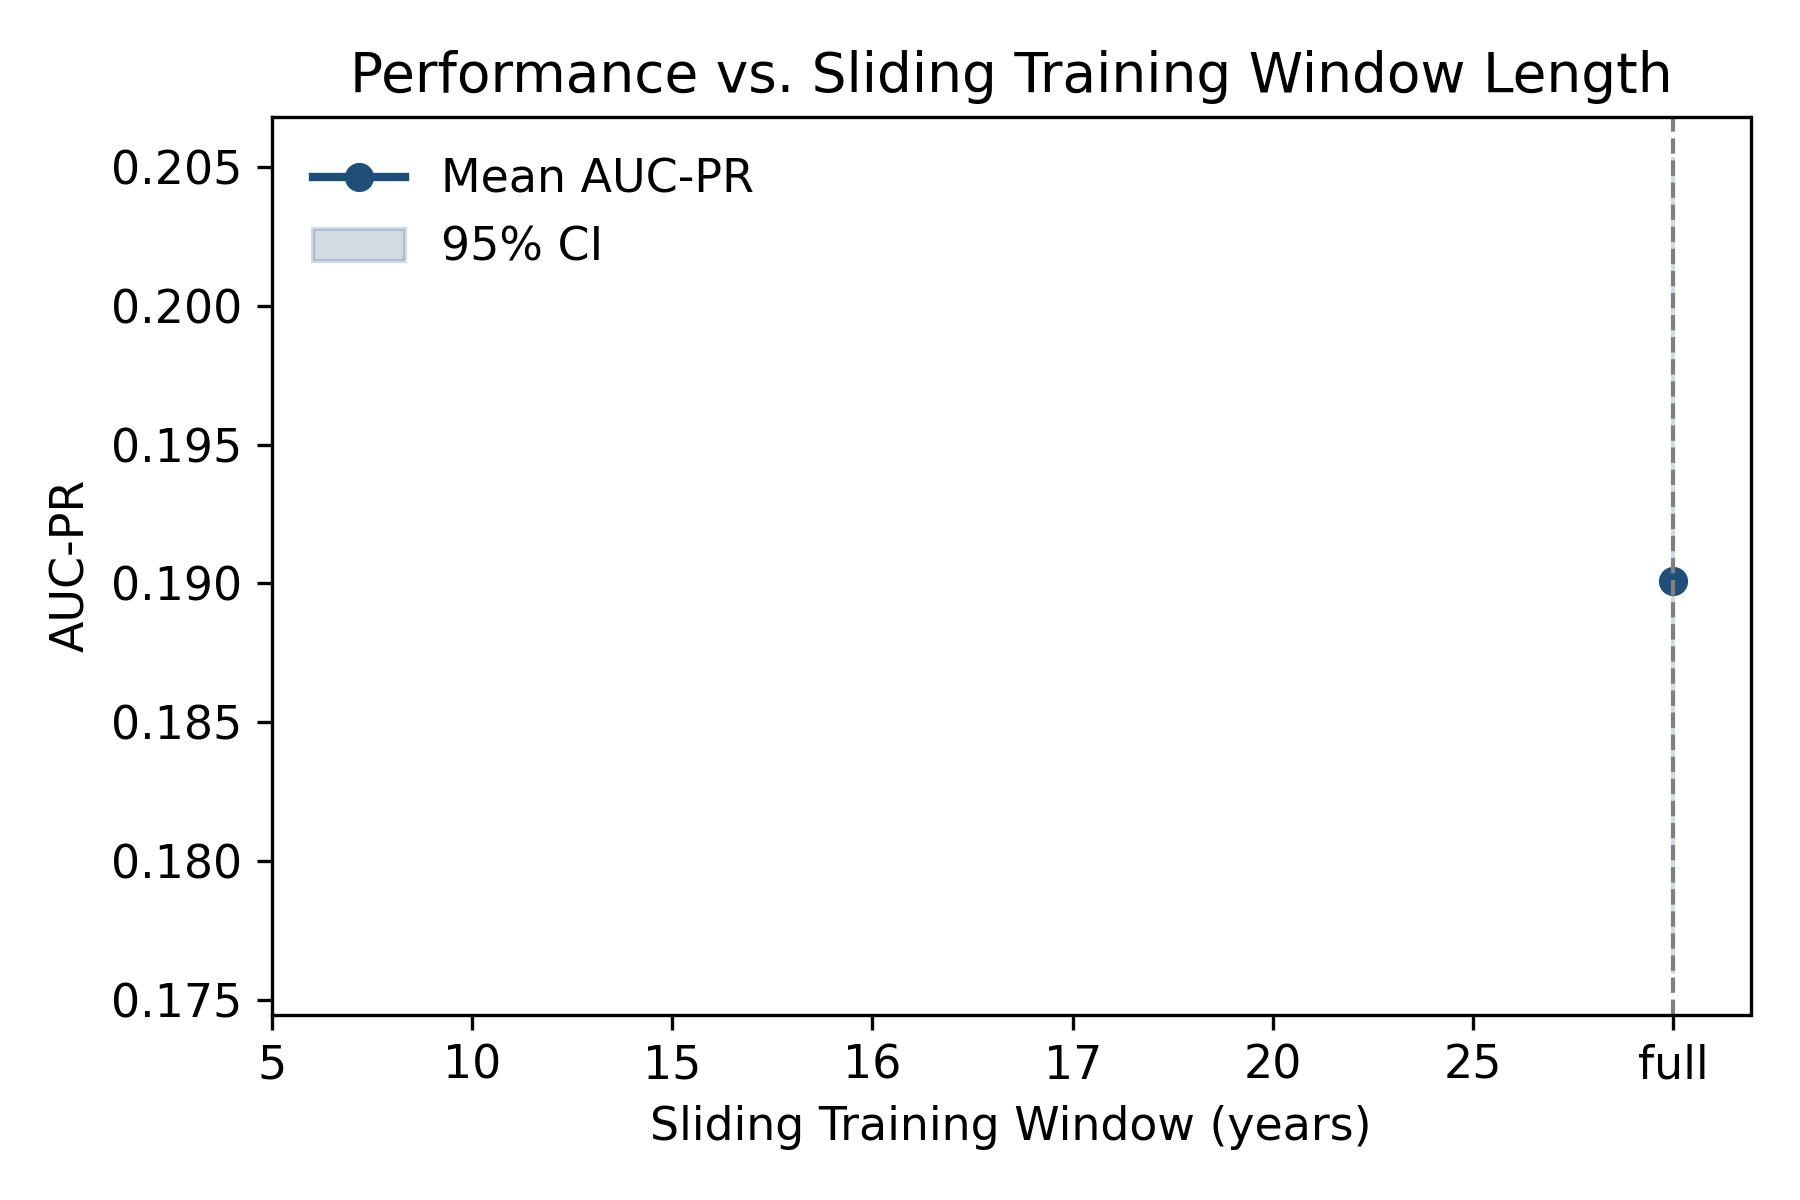


--- Feature ablation (RQ1 — DI contribution) ---


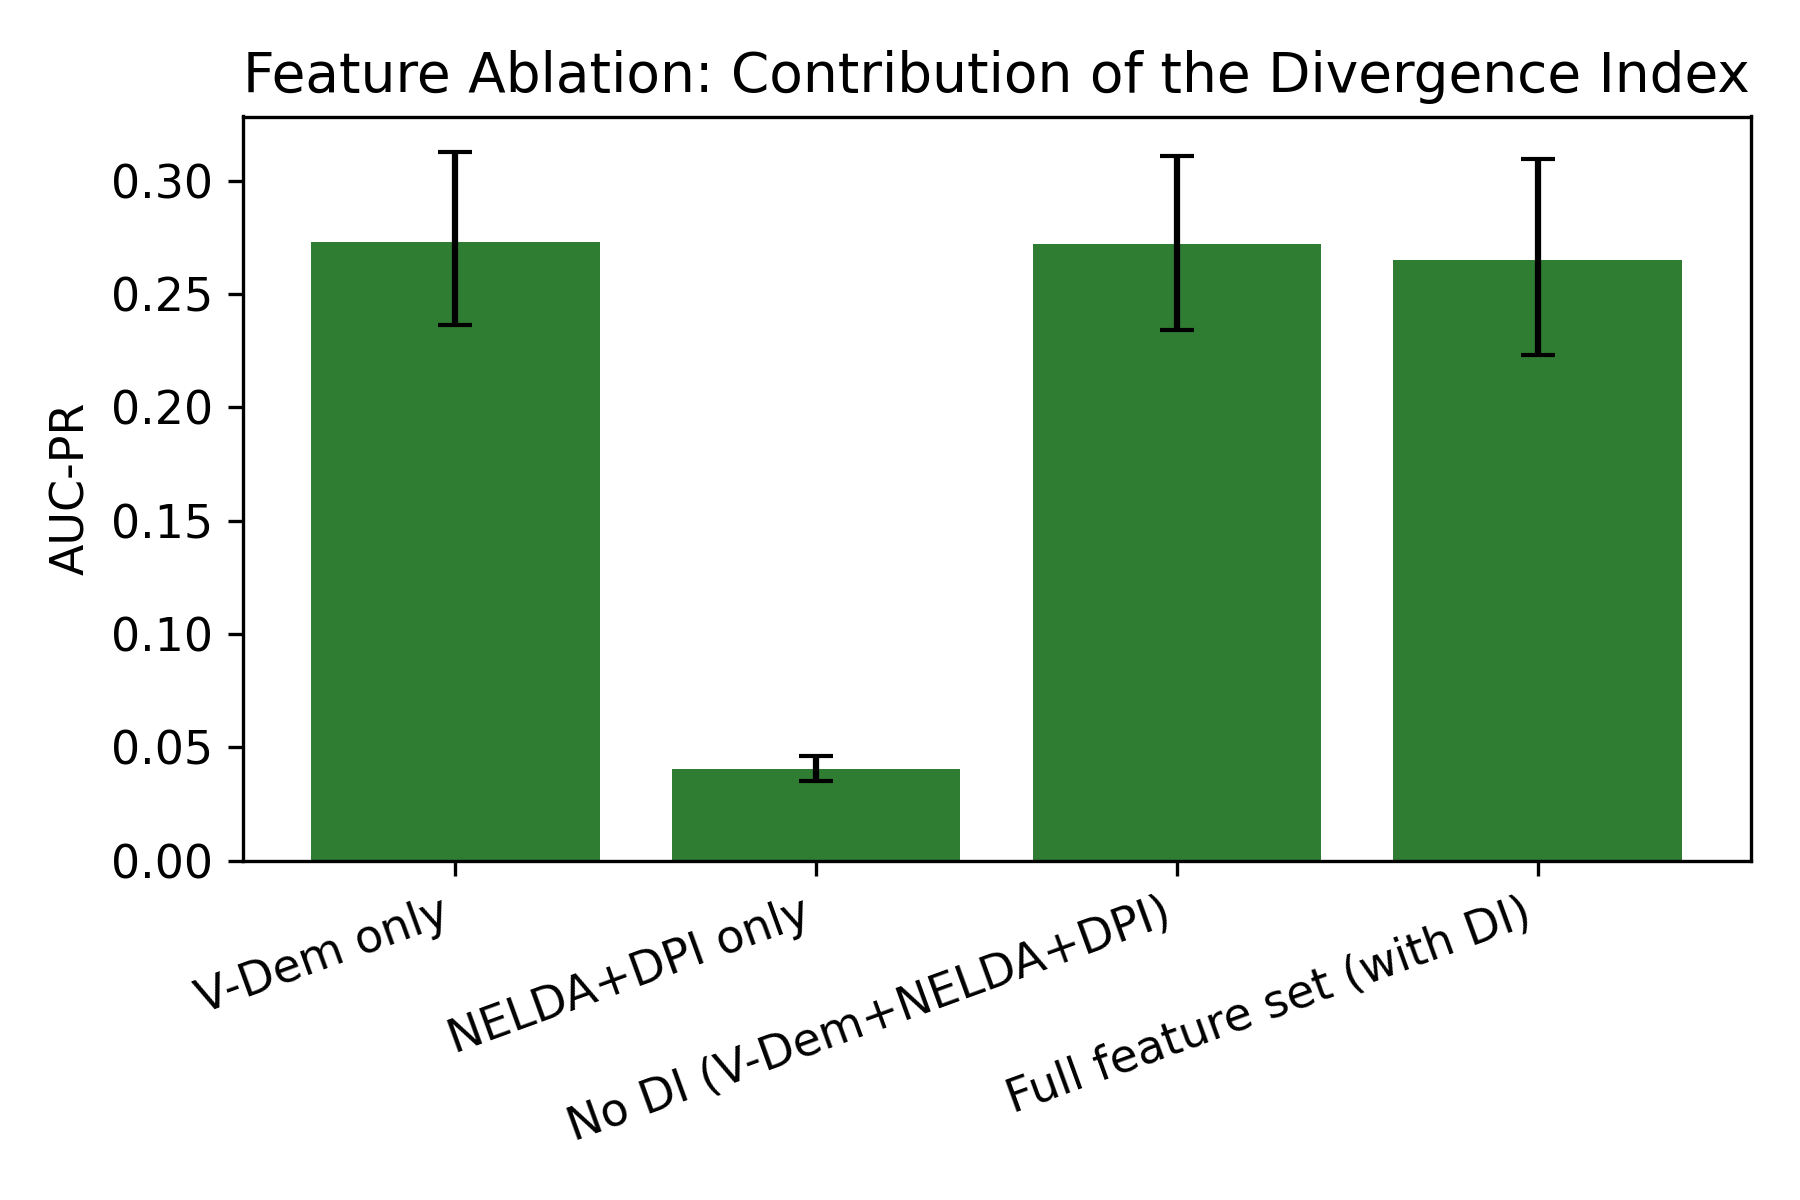


--- Precision-Recall curve (final model) ---


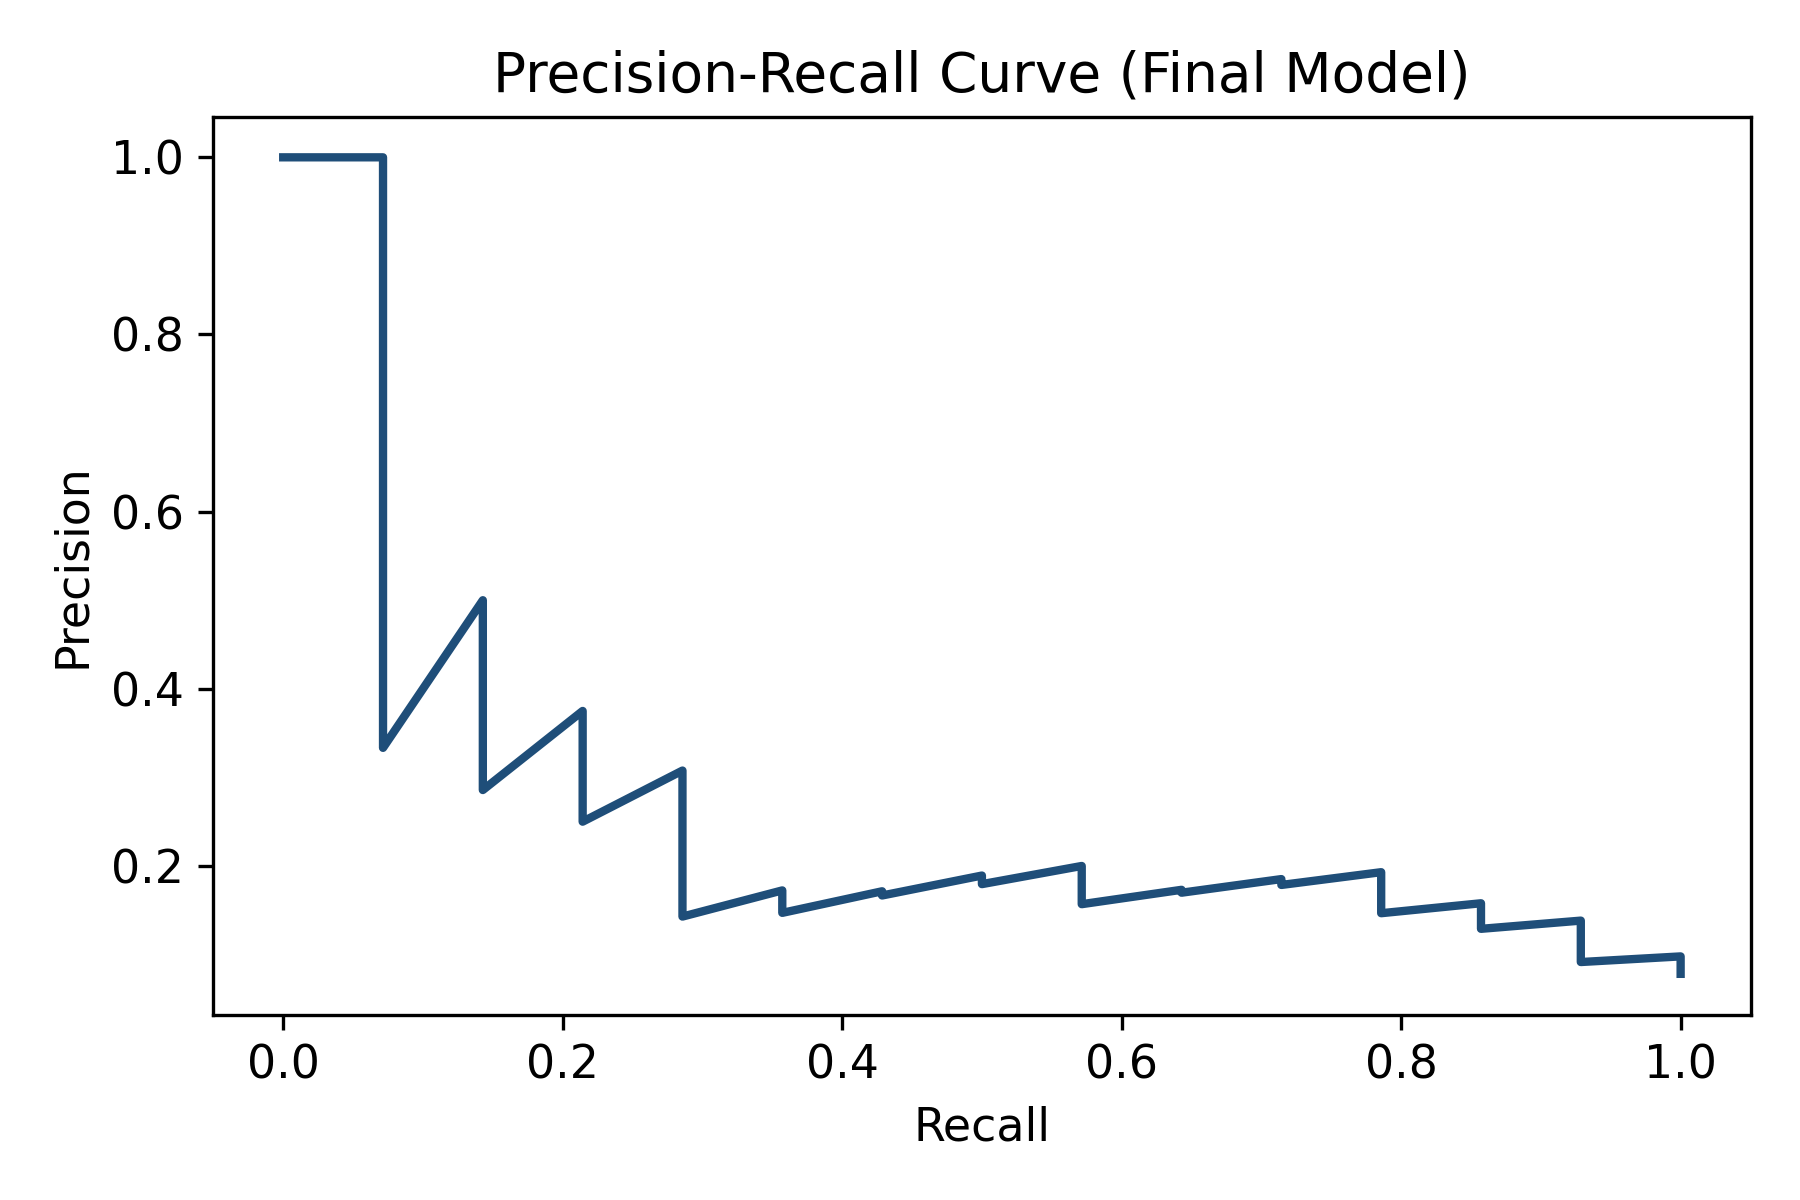


--- Base learners vs. ensemble ---


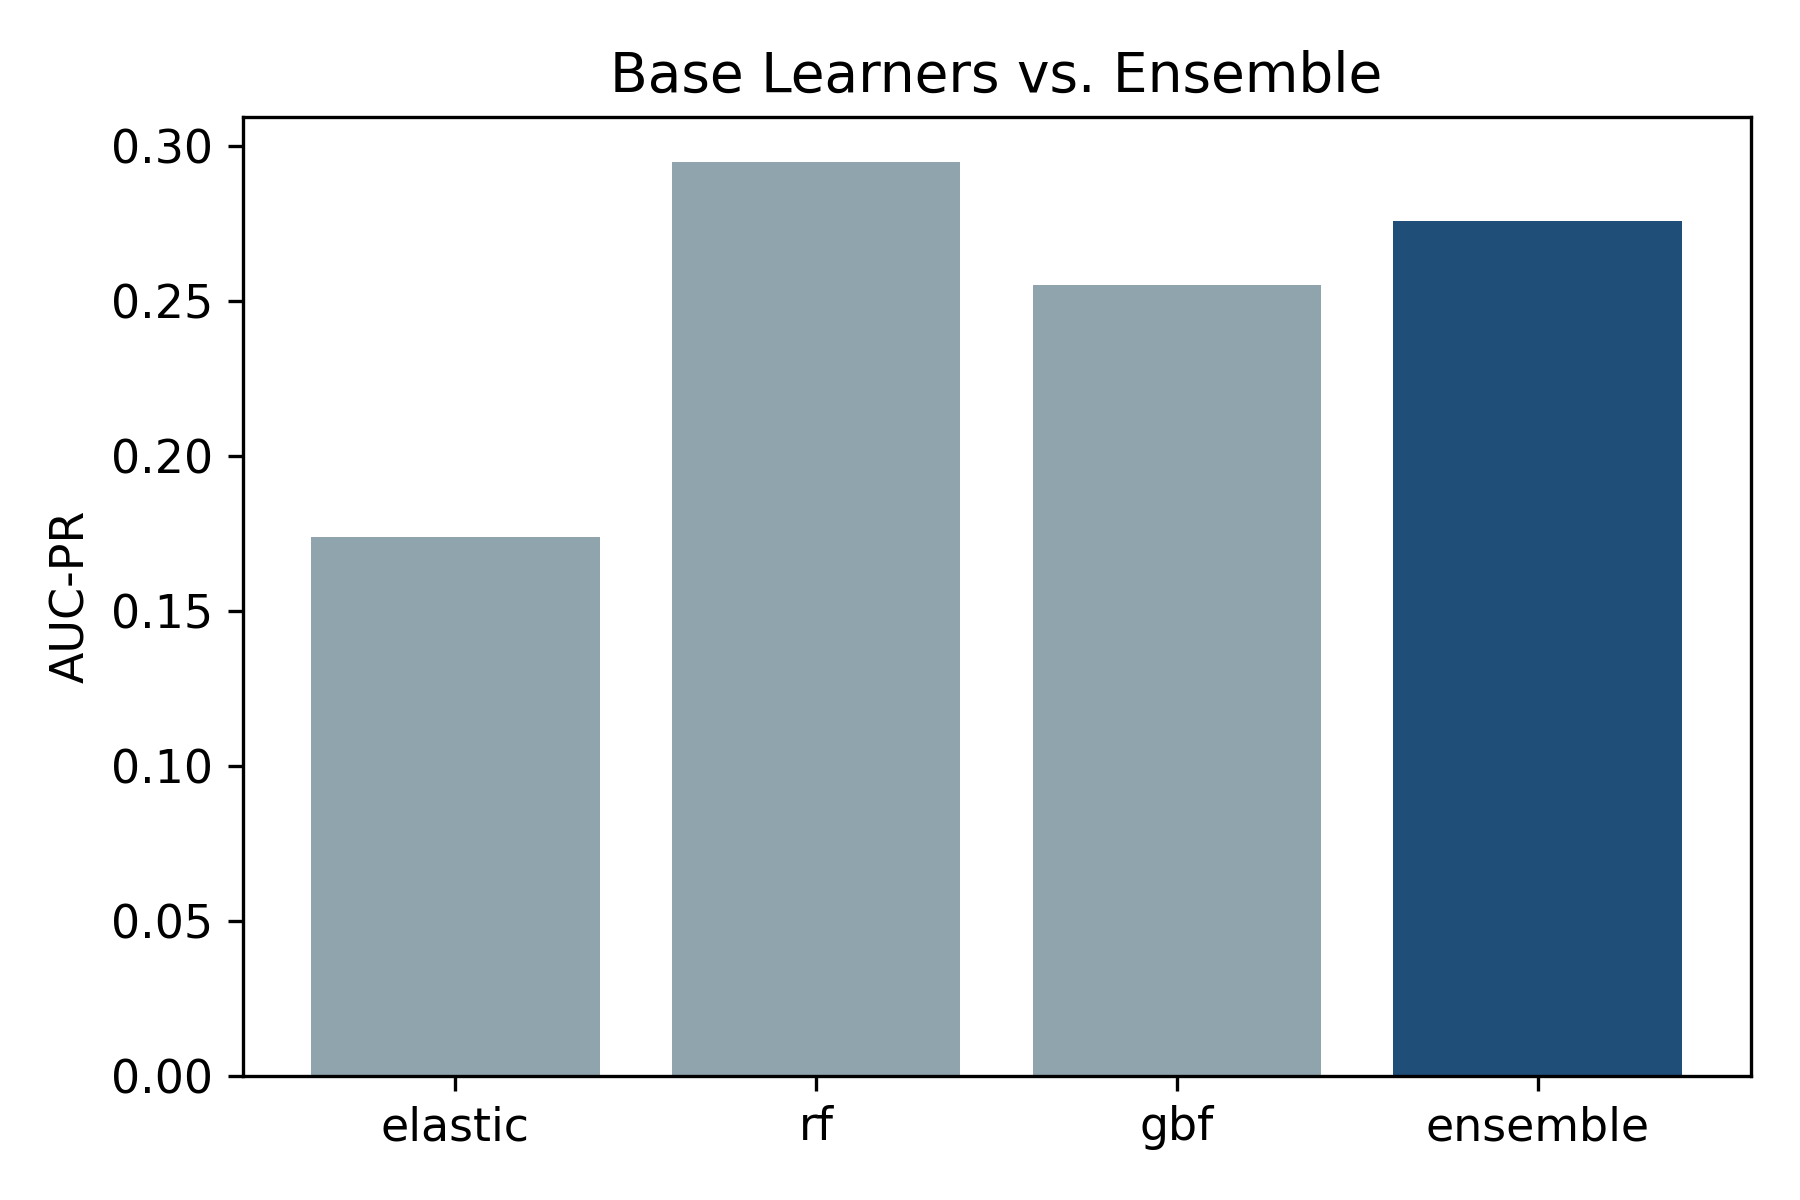


--- Calibration / reliability diagram ---


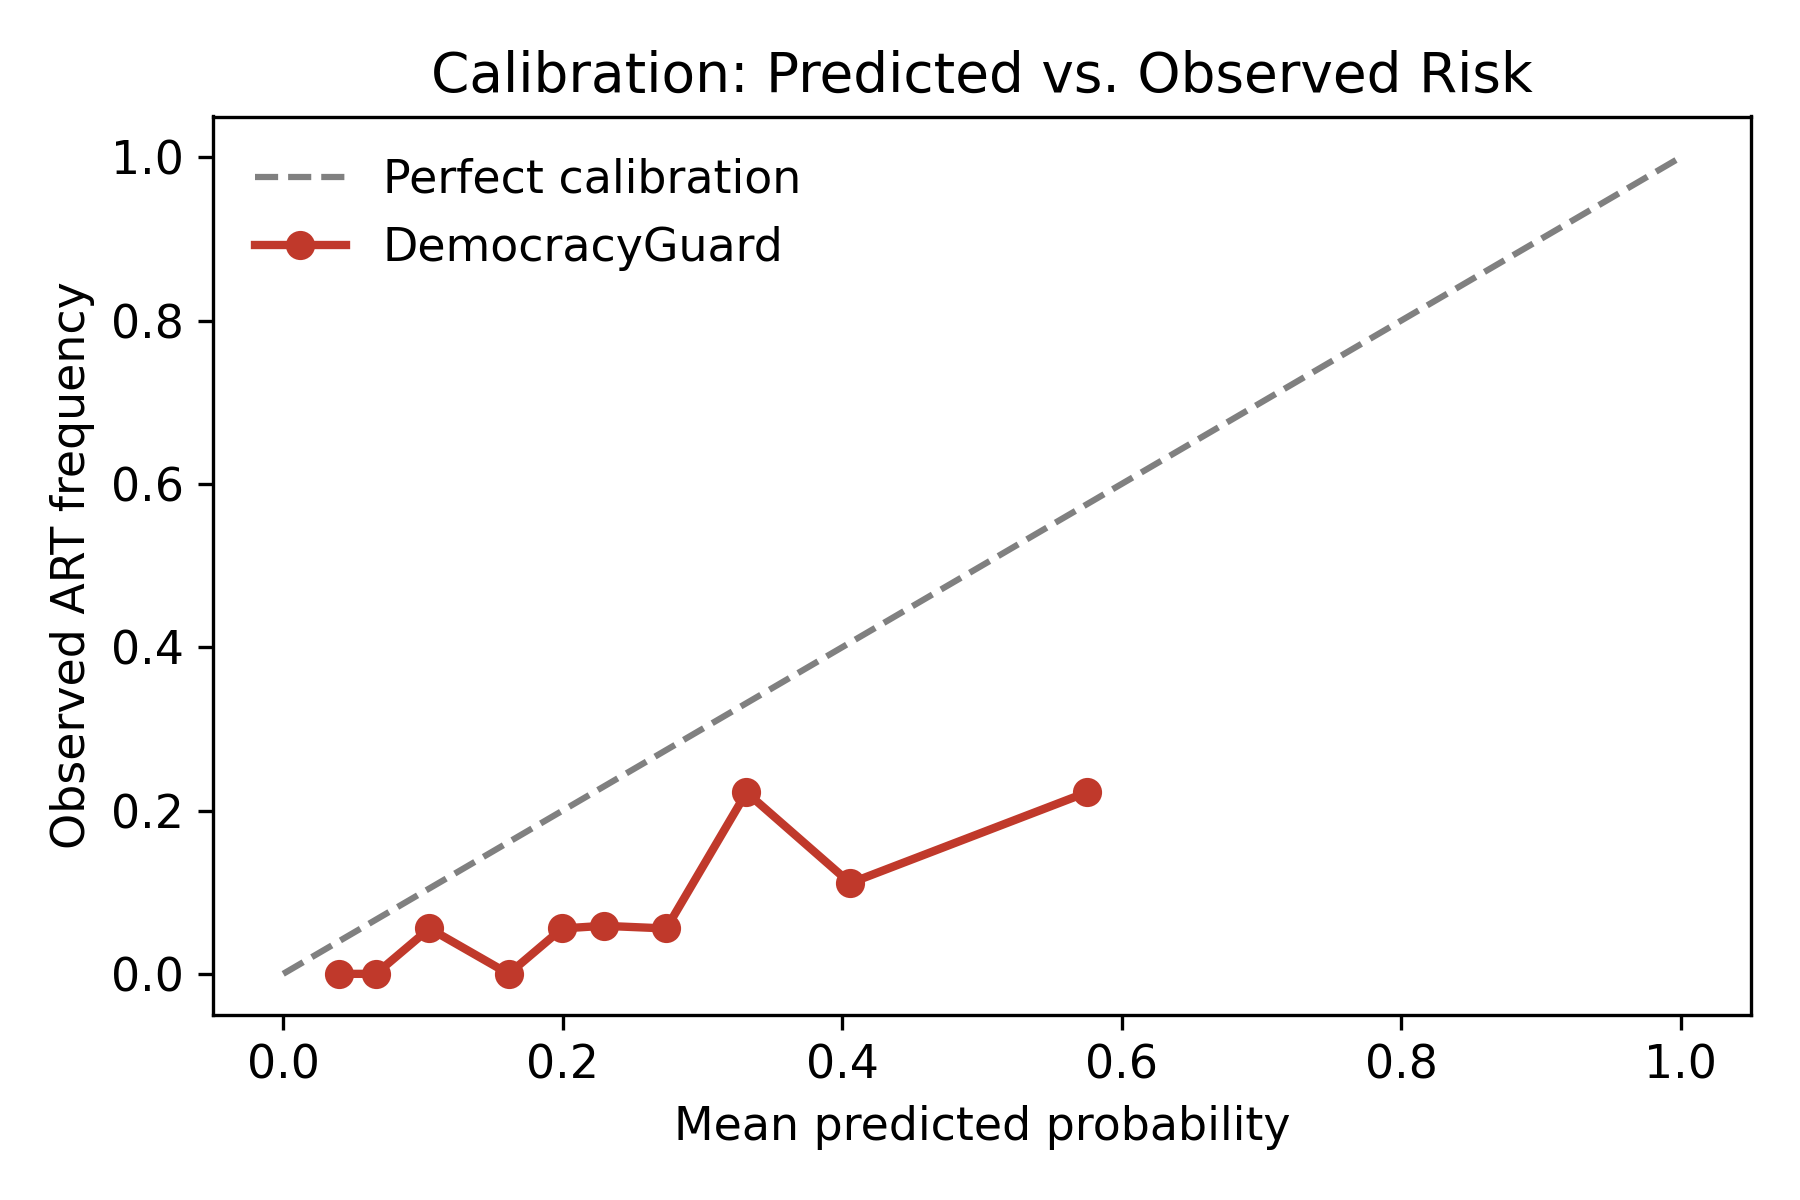


--- SHAP decay-profile clusters ---


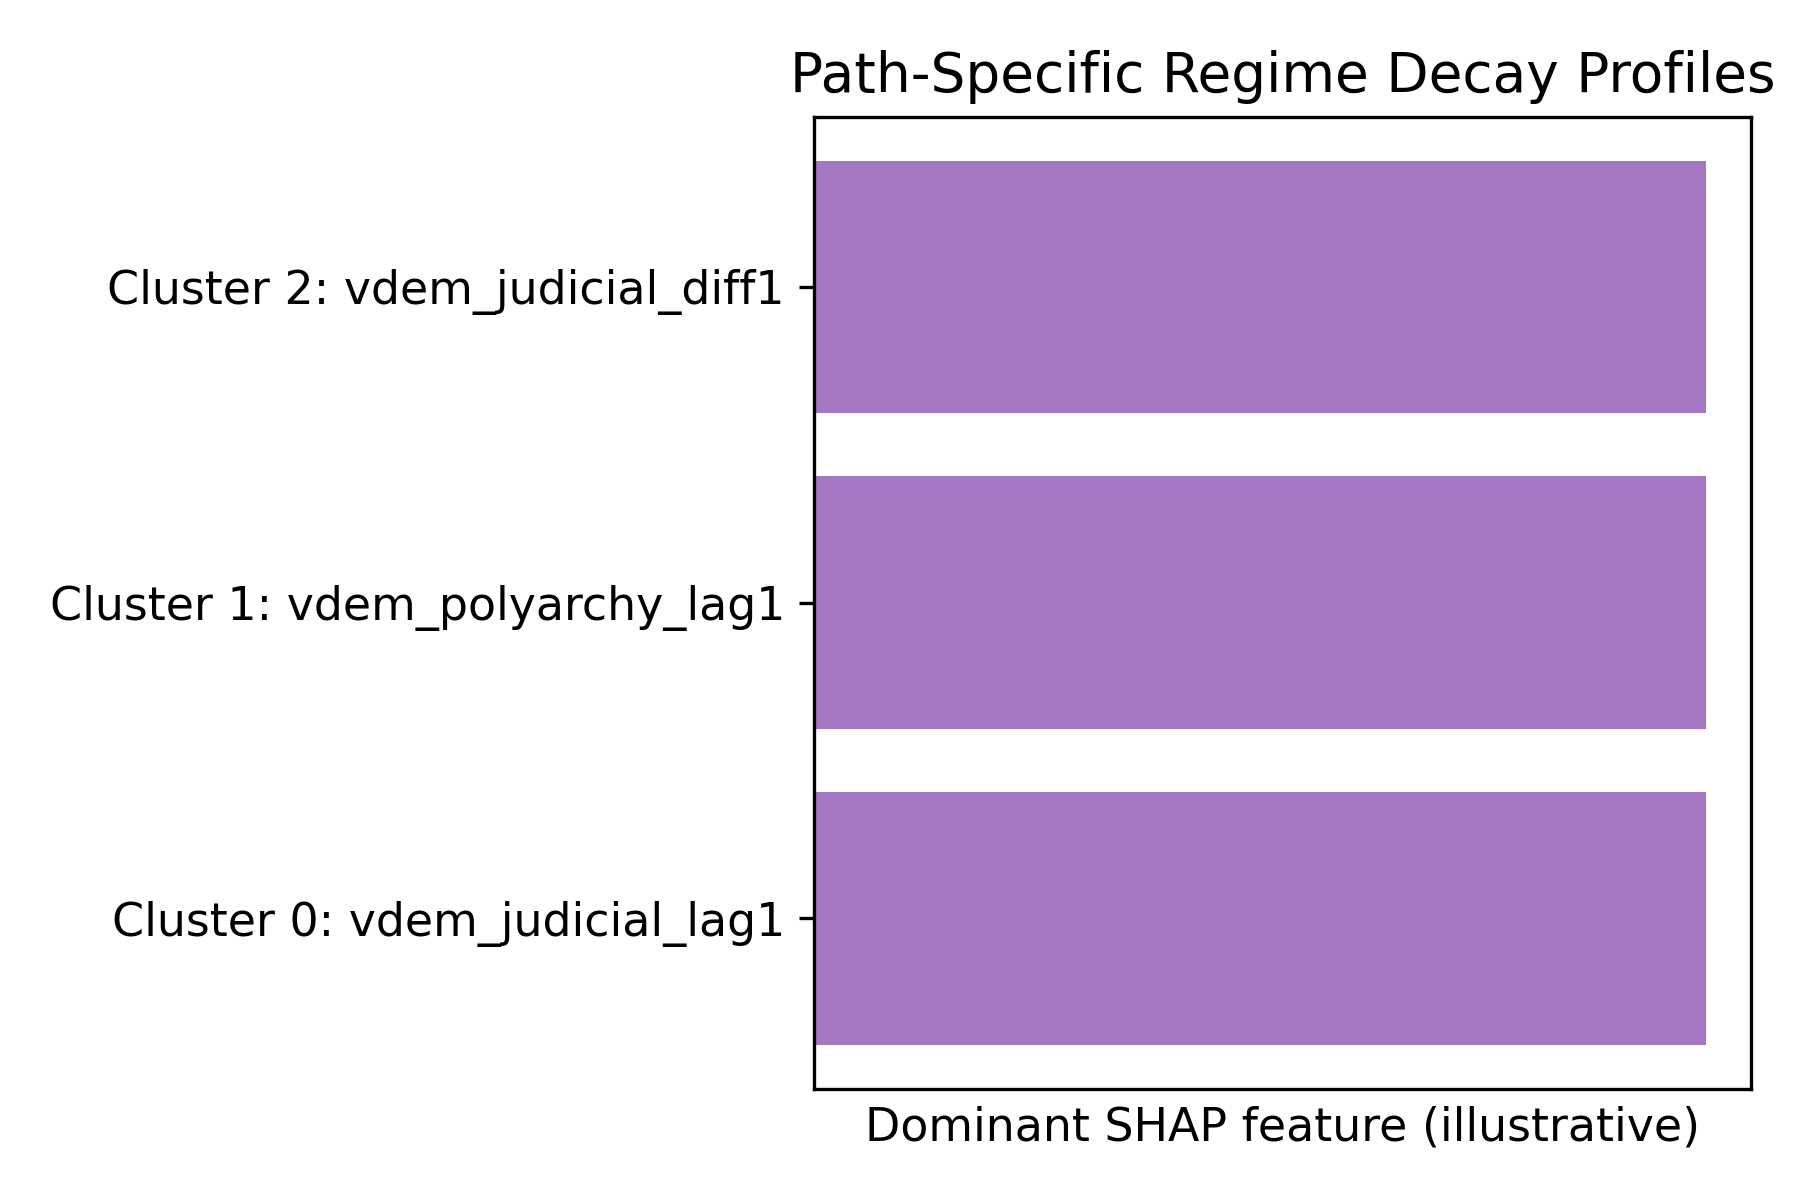

In [24]:
# ============================================================
# Cell 9 — Display all pipeline figures inline
# (Agg backend saved these to disk in stages 4-7 but never
# showed them in the notebook — this just reads them back.)
# ============================================================
from IPython.display import Image, display
import os

figures_to_show = [
    ("Sliding Training Window sweep",        "fig_stw_sweep.png"),
    ("Feature ablation (RQ1 — DI contribution)", "fig_feature_ablation.png"),
    ("Precision-Recall curve (final model)",  "fig_pr_curve.png"),
    ("Base learners vs. ensemble",            "fig_ensemble_components.png"),
    ("Calibration / reliability diagram",     "fig_calibration.png"),
    ("SHAP decay-profile clusters",           "fig_shap_clusters.png"),
]

for title, fname in figures_to_show:
    path = os.path.join(FIG_DIR, fname)
    print(f"--- {title} ---")
    if os.path.exists(path):
        display(Image(filename=path))
    else:
        print(f"  [MISSING] {path} was not found — that stage may not have "
              f"produced this figure (e.g. shap wasn't installed for the SHAP-cluster figure).")
    print()

### [10] Package figures + LaTeX tables into a zip

Bundles the PNG figures and the `.tex` table snippets already generated by the pipeline (`table_stw_summary.tex`, `table_ablation.tex`, `table_calibration.tex`, `table_model_comparison.tex`) into a single zip, ready to upload into an Overleaf project's `figures/` folder alongside `main.tex`.

In [25]:
# ============================================================
# Cell 10 — Package all figures + LaTeX tables into a zip
# for easy download / upload to Overleaf
# ============================================================
import shutil
import zipfile

zip_base = os.path.join(OUTPUT_DIR, "democracyguard_paper_assets")
zip_path = shutil.make_archive(zip_base, "zip", OUTPUT_DIR, "figures")

# also fold the tables directory into the same zip
with zipfile.ZipFile(zip_path, "a") as zf:
    for fname in os.listdir(TAB_DIR):
        zf.write(os.path.join(TAB_DIR, fname), arcname=os.path.join("tables", fname))

print(f"Zipped figures + tables to: {zip_path}")

try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print("Not running in Colab — find the zip at the path printed above (e.g. in Drive).")

Zipped figures + tables to: /content/drive/MyDrive/DATASETS_For the data analysis/DemocracyShield Datasets/results/democracyguard_paper_assets.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>